# AMR mechanism discovery: AmpR, β-lactamase, and ceftazidime resistance

This notebook applies the Semantic Graphicalizer to a compact microbiology case study. It uses a hand-built scientific ontology and a deterministic graph compiled from the causal claims in one research abstract. No language model or network access is needed to run the graph cells.

## Source study

Gifford, D. R., Furió, V., Papkou, A., Vogwill, T., Oliver, A. & MacLean, R. C. (2018). [Identifying and exploiting genes that potentiate the evolution of antibiotic resistance](https://www.nature.com/articles/s41559-018-0547-x). *Nature Ecology & Evolution*, 2, 1033–1039. DOI: [10.1038/s41559-018-0547-x](https://doi.org/10.1038/s41559-018-0547-x).

The abstract reports a causal mechanism: in *Pseudomonas*, the global regulator **AmpR** permits mutations in conserved peptidoglycan-biosynthesis genes to induce high β-lactamase expression, which raises the rate of de novo ceftazidime resistance. The study also reports that co-administering the β-lactamase inhibitor **avibactam** can block this evolutionary pathway.

The notebook separates three layers that are often conflated in scientific text:

- **Mechanism:** biological entities and causal links between them.
- **Evidence:** the experiment and propositions it supports.
- **Intervention:** the inhibitor and the pathway-level claim it prevents.

In [1]:
%matplotlib inline

from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx

from semantic_graphicalizer import (
    Argument,
    Entity,
    RelationInstance,
    display_graph,
    graph_to_text,
    load_ontology,
    project_binary_relations,
    validate_graph,
)
from semantic_graphicalizer.graph import materialize_graph

## 1. A microbiology ontology for AMR

The ontology distinguishes biological objects (`Gene`, `Regulator`, `Protein`, `Mutation`), microbiological context (`Strain`, `Population`, `Experiment`), and scientific claims (`Proposition`).

The crucial recursive rule is the same as in the minimal notebook: `Proposition` is an entity type. Therefore an evidence relation can support a causal proposition, and an inhibitor can prevent a proposition describing an evolutionary pathway.

In [2]:
scientific_types = [
    ('Organism', 'A microbial taxon or species.'),
    ('Strain', 'A laboratory or clinical bacterial strain.'),
    ('Population', 'A population of bacterial cells or evolved lineages.'),
    ('Gene', 'A genomic locus or coding sequence.'),
    ('Regulator', 'A regulatory protein or transcriptional regulator.'),
    ('Protein', 'A protein product or resistance enzyme.'),
    ('Mutation', 'A heritable sequence change.'),
    ('Pathway', 'A cellular biosynthetic or regulatory pathway.'),
    ('Antibiotic', 'An antibacterial compound used as selective pressure.'),
    ('Inhibitor', 'An adjuvant that inhibits a resistance mechanism.'),
    ('Phenotype', 'An observed susceptibility or resistance phenotype.'),
    ('Experiment', 'An experimental evolution or microbiology study.'),
    ('Proposition', 'A reified scientific assertion with typed arguments.'),
]

all_scientific_types = [item[0] for item in scientific_types]
ontology = load_ontology({
    'name': 'microbiology-amr',
    'version': '1.0',
    'terms': [{'id': term_id, 'description': description} for term_id, description in scientific_types],
    'argument_roles': [
        {'id': 'subject', 'description': 'The entity carrying or undergoing a property.'},
        {'id': 'object', 'description': 'The entity affected or related to the subject.'},
        {'id': 'cause', 'description': 'The cause side of a causal assertion.'},
        {'id': 'effect', 'description': 'The effect side of a causal assertion.'},
        {'id': 'pressure', 'description': 'The antibiotic selection pressure.'},
        {'id': 'outcome', 'description': 'The selected outcome or phenotype.'},
        {'id': 'evidence', 'description': 'An experiment or result supporting a claim.'},
        {'id': 'claim', 'description': 'A scientific proposition supported by evidence.'},
        {'id': 'intervention', 'description': 'An inhibitor or treatment intervention.'},
        {'id': 'target', 'description': 'The mechanism, protein, or phenotype affected.'},
        {'id': 'experiment', 'description': 'The experiment performing an observation.'},
    ],
    'relations': {
        'has_factor': {
            'description': 'A strain contains or carries a biological factor.',
            'arguments': {
                'subject': {'cardinality': 1, 'allowed_types': ['Strain', 'Organism']},
                'object': {'cardinality': 1, 'allowed_types': ['Gene', 'Regulator', 'Protein']},
            },
            'projection': ['subject', 'object'],
        },
        'belongs_to_pathway': {
            'description': 'A mutation or molecular factor belongs to a cellular pathway.',
            'arguments': {
                'subject': {'cardinality': 1, 'allowed_types': ['Gene', 'Protein', 'Mutation']},
                'object': {'cardinality': 1, 'allowed_types': ['Pathway']},
            },
            'projection': ['subject', 'object'],
        },
        'causes': {
            'description': 'A biological factor or proposition causes a downstream scientific effect.',
            'arguments': {
                'cause': {'cardinality': 1, 'allowed_types': all_scientific_types},
                'effect': {'cardinality': 1, 'allowed_types': all_scientific_types},
            },
            'projection': ['cause', 'effect'],
            'category': 'causal',
        },
        'selects_for': {
            'description': 'An antibiotic pressure selects for a resistance outcome.',
            'arguments': {
                'pressure': {'cardinality': 1, 'allowed_types': ['Antibiotic']},
                'outcome': {'cardinality': 1, 'allowed_types': ['Mutation', 'Phenotype', 'Population']},
            },
            'projection': ['pressure', 'outcome'],
            'category': 'causal',
        },
        'supports': {
            'description': 'Evidence supports a scientific proposition.',
            'arguments': {
                'evidence': {'cardinality': 1, 'allowed_types': ['Experiment', 'Proposition']},
                'claim': {'cardinality': 1, 'allowed_types': ['Proposition']},
            },
            'projection': ['evidence', 'claim'],
        },
        'blocks': {
            'description': 'An inhibitor blocks a resistance protein or mechanism.',
            'arguments': {
                'intervention': {'cardinality': 1, 'allowed_types': ['Inhibitor']},
                'target': {'cardinality': 1, 'allowed_types': ['Protein', 'Pathway', 'Phenotype', 'Proposition']},
            },
            'projection': ['intervention', 'target'],
            'category': 'causal',
        },
        'prevents': {
            'description': 'An intervention prevents a resistance outcome or evolutionary proposition.',
            'arguments': {
                'intervention': {'cardinality': 1, 'allowed_types': ['Inhibitor']},
                'target': {'cardinality': 1, 'allowed_types': ['Mutation', 'Phenotype', 'Population', 'Proposition']},
            },
            'projection': ['intervention', 'target'],
            'category': 'causal',
        },
        'studies': {
            'description': 'An experiment studies a strain or population.',
            'arguments': {
                'experiment': {'cardinality': 1, 'allowed_types': ['Experiment']},
                'subject': {'cardinality': 1, 'allowed_types': ['Organism', 'Strain', 'Population']},
            },
            'projection': ['experiment', 'subject'],
        },
    },
})

print(ontology.as_prompt())

Ontology: microbiology-amr (version 1.0)
Entity types:
- Organism: A microbial taxon or species.
- Strain: A laboratory or clinical bacterial strain.
- Population: A population of bacterial cells or evolved lineages.
- Gene: A genomic locus or coding sequence.
- Regulator: A regulatory protein or transcriptional regulator.
- Protein: A protein product or resistance enzyme.
- Mutation: A heritable sequence change.
- Pathway: A cellular biosynthetic or regulatory pathway.
- Antibiotic: An antibacterial compound used as selective pressure.
- Inhibitor: An adjuvant that inhibits a resistance mechanism.
- Phenotype: An observed susceptibility or resistance phenotype.
- Experiment: An experimental evolution or microbiology study.
- Proposition: A reified scientific assertion with typed arguments.
Argument roles:
- subject: The entity carrying or undergoing a property.
- object: The entity affected or related to the subject.
- cause: The cause side of a causal assertion.
- effect: The effect 

## 2. Encode the abstract as typed entities and propositions

The central mechanism is represented as three causal propositions:

```text
AmpR → peptidoglycan-biosynthesis mutation → β-lactamase expression → ceftazidime resistance
```

The experiment supports each link. A second proposition represents the intervention result: avibactam blocks β-lactamase and prevents the antibiotic-selection pathway.

In [3]:
entities = [
    Entity('pseudomonas-aeruginosa', 'Organism', attributes={'mentions': ['Pseudomonas aeruginosa']}),
    Entity('pao1', 'Strain', attributes={'mentions': ['PAO1']}),
    Entity('ampR', 'Regulator', attributes={'mentions': ['AmpR global transcriptional regulator']}),
    Entity('pg-biosynthesis-mutation', 'Mutation', attributes={'mentions': ['conserved peptidoglycan-biosynthesis mutation']}),
    Entity('peptidoglycan-biosynthesis', 'Pathway', attributes={'mentions': ['peptidoglycan biosynthesis']}),
    Entity('beta-lactamase', 'Protein', attributes={'mentions': ['β-lactamase expression']}),
    Entity('ceftazidime', 'Antibiotic', attributes={'mentions': ['ceftazidime']}),
    Entity('ceftazidime-resistance', 'Phenotype', attributes={'mentions': ['de novo ceftazidime resistance']}),
    Entity('avibactam', 'Inhibitor', attributes={'mentions': ['avibactam']}),
    Entity('evolution-experiment', 'Experiment', attributes={'mentions': ['experimental evolution across Pseudomonas']}),
]

propositions = [
    RelationInstance(
        'prop::ampR-potentiates-mutation', 'Proposition', 'causes',
        (Argument('cause', 'ampR'), Argument('effect', 'pg-biosynthesis-mutation')),
        {'mentions': ['AmpR potentiates the evolution of the mutation'], 'claim_role': 'mechanism'},
    ),
    RelationInstance(
        'prop::mutation-induces-beta-lactamase', 'Proposition', 'causes',
        (Argument('cause', 'pg-biosynthesis-mutation'), Argument('effect', 'beta-lactamase')),
        {'mentions': ['the mutation induces high β-lactamase expression'], 'claim_role': 'mechanism'},
    ),
    RelationInstance(
        'prop::beta-lactamase-confers-resistance', 'Proposition', 'causes',
        (Argument('cause', 'beta-lactamase'), Argument('effect', 'ceftazidime-resistance')),
        {'mentions': ['β-lactamase expression raises ceftazidime resistance'], 'claim_role': 'mechanism'},
    ),
    RelationInstance(
        'prop::ceftazidime-selects-resistance', 'Proposition', 'selects_for',
        (Argument('pressure', 'ceftazidime'), Argument('outcome', 'ceftazidime-resistance')),
        {'mentions': ['ceftazidime selection for resistance'], 'claim_role': 'selection'},
    ),
    RelationInstance(
        'prop::avibactam-blocks-beta-lactamase', 'Proposition', 'blocks',
        (Argument('intervention', 'avibactam'), Argument('target', 'beta-lactamase')),
        {'mentions': ['avibactam inhibits β-lactamase'], 'claim_role': 'intervention'},
    ),
    RelationInstance(
        'prop::avibactam-prevents-selection-pathway', 'Proposition', 'prevents',
        (Argument('intervention', 'avibactam'), Argument('target', 'prop::ceftazidime-selects-resistance')),
        {'mentions': ['avibactam blocks the evolutionary pathway before resistance emerges'], 'claim_role': 'intervention'},
    ),
    RelationInstance(
        'prop::ampR-carried-by-pao1', 'Proposition', 'has_factor',
        (Argument('subject', 'pao1'), Argument('object', 'ampR')),
        {'mentions': ['PAO1 carries ampR'], 'claim_role': 'context'},
    ),
    RelationInstance(
        'prop::mutation-in-pathway', 'Proposition', 'belongs_to_pathway',
        (Argument('subject', 'pg-biosynthesis-mutation'), Argument('object', 'peptidoglycan-biosynthesis')),
        {'mentions': ['mutation in peptidoglycan biosynthesis'], 'claim_role': 'context'},
    ),
    RelationInstance(
        'prop::experiment-studies-pao1', 'Proposition', 'studies',
        (Argument('experiment', 'evolution-experiment'), Argument('subject', 'pao1')),
        {'mentions': ['experimental evolution in Pseudomonas strains'], 'claim_role': 'evidence'},
    ),
]

evidence_relations = [
    RelationInstance(
        f'prop::experiment-supports-{claim_id.split("::")[-1]}', 'Proposition', 'supports',
        (Argument('evidence', 'evolution-experiment'), Argument('claim', claim_id)),
        {'mentions': [f'experiment supports {claim_id}'], 'claim_role': 'evidence'},
    )
    for claim_id in [
        'prop::ampR-potentiates-mutation',
        'prop::mutation-induces-beta-lactamase',
        'prop::beta-lactamase-confers-resistance',
        'prop::avibactam-prevents-selection-pathway',
    ]
]

graph = materialize_graph(
    entities,
    propositions + evidence_relations,
    ontology,
    document_id='amr-ampR-mechanism',
    document_text='Causal mechanism of AmpR-potentiated ceftazidime resistance in Pseudomonas.',
)
validate_graph(graph, ontology)

relation_nodes = [node for node, data in graph.nodes(data=True) if data['relation'] is not None]
print(f'{graph.number_of_nodes()} total entities; {len(relation_nodes)} are reified propositions')
print(f'{graph.number_of_edges()} typed argument edges')
print('Validation: OK')

23 total entities; 13 are reified propositions
26 typed argument edges
Validation: OK


## 3. Canonical scientific graph

This is the fully reified view. Orange relation entities are propositions; gray nodes are biological objects, experimental context, or interventions. Argument roles stay visible, so the distinction between `cause`, `effect`, `evidence`, and `claim` is not lost.

In [9]:
display_graph(
    graph,
    mode='dynamic',
    show_derived_links=True,
    show_source=True,
    max_width=31,
    width=1600,
    height=980,
)

In [5]:
print(graph_to_text(graph, show_derived_links=False))

proposition [causes]: AmpR potentiates the evolution of the mutation
    cause: regulator: AmpR global transcriptional regulator
    effect: mutation: conserved peptidoglycan-biosynthesis mutation
proposition [causes]: the mutation induces high β-lactamase expression
    cause: mutation: conserved peptidoglycan-biosynthesis mutation
    effect: protein: β-lactamase expression
proposition [causes]: β-lactamase expression raises ceftazidime resistance
    cause: protein: β-lactamase expression
    effect: phenotype: de novo ceftazidime resistance
proposition [selects_for]: ceftazidime selection for resistance
    pressure: antibiotic: ceftazidime
    outcome: phenotype: de novo ceftazidime resistance
proposition [blocks]: avibactam inhibits β-lactamase
    intervention: inhibitor: avibactam
    target: protein: β-lactamase expression
proposition [prevents]: avibactam blocks the evolutionary pathway before resistance emerges
    intervention: inhibitor: avibactam
    target: proposition: 

## 4. Projected causal and evidence graph

Projection creates direct edges for binary relations while preserving proposition nodes. This makes the main causal pathway easy to scan, but still leaves evidence relations attached to the propositions they support.

In [10]:
projected = project_binary_relations(graph, ontology)

display_graph(
    projected,
    mode='dynamic',
    show_source=True,
    max_width=31,
    width=1600,
    height=900,
)

In [7]:
print('Projected edges involving a reified proposition:')
for source, target, data in projected.edges(data=True):
    if graph.nodes[source]['relation'] is not None or graph.nodes[target]['relation'] is not None:
        print(f"{source} --{data['predicate']}--> {target}")

assert any(graph.nodes[target]['relation'] is not None for _source, target in projected.edges())
assert any(graph.nodes[source]['relation'] is not None for source, _target in graph.edges())
print('\nRecursive scientific claims remain explicit after projection.')

Projected edges involving a reified proposition:
avibactam --prevents--> prop::ceftazidime-selects-resistance
evolution-experiment --supports--> prop::ampR-potentiates-mutation
evolution-experiment --supports--> prop::mutation-induces-beta-lactamase
evolution-experiment --supports--> prop::beta-lactamase-confers-resistance
evolution-experiment --supports--> prop::avibactam-prevents-selection-pathway

Recursive scientific claims remain explicit after projection.


## 5. Plot the mechanism as a causal chain

The graph renderer is best for ontology structure. This compact plot is complementary: it isolates the biological mechanism and the intervention, using a left-to-right causal layout.

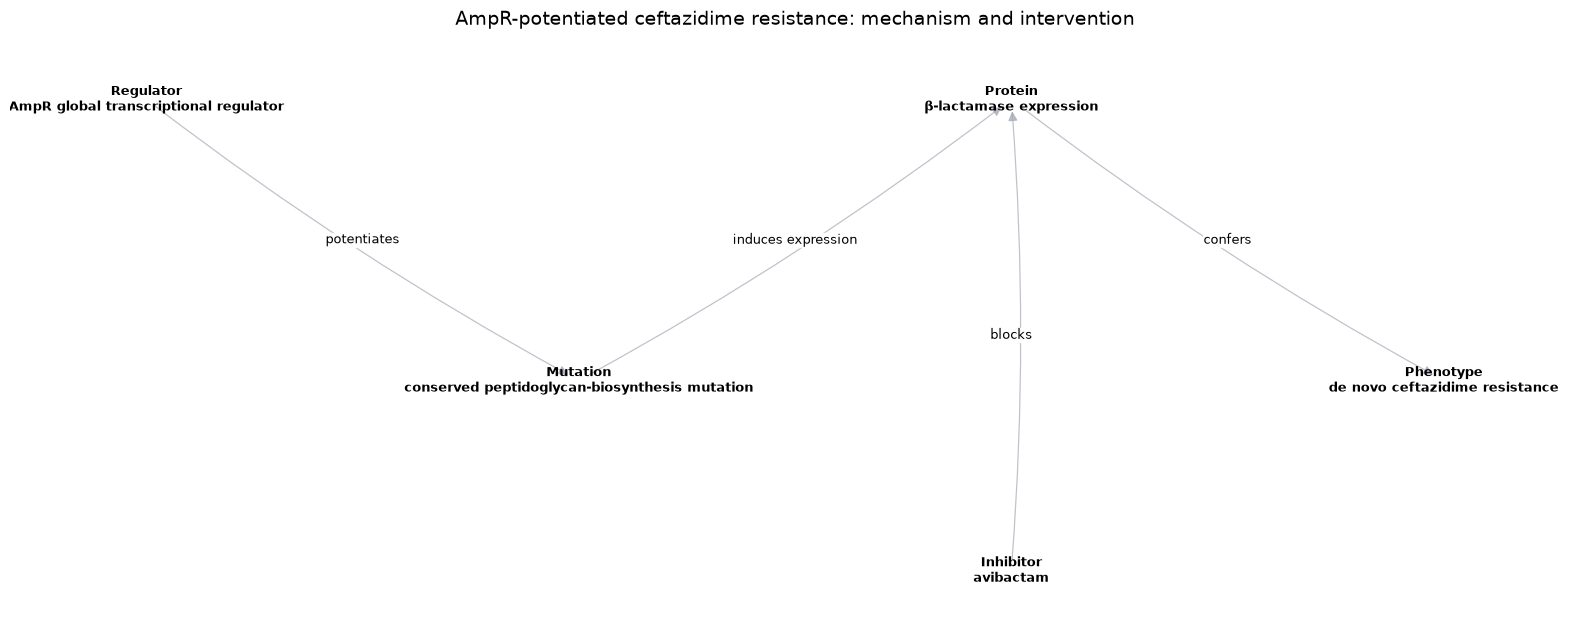

In [14]:
mechanism_nodes = [
    'ampR',
    'pg-biosynthesis-mutation',
    'beta-lactamase',
    'ceftazidime-resistance',
]
mechanism_graph = nx.DiGraph()
mechanism_graph.add_nodes_from(mechanism_nodes)
mechanism_graph.add_edges_from([
    ('ampR', 'pg-biosynthesis-mutation', {'label': 'potentiates'}),
    ('pg-biosynthesis-mutation', 'beta-lactamase', {'label': 'induces expression'}),
    ('beta-lactamase', 'ceftazidime-resistance', {'label': 'confers'}),
])

position = {
    'ampR': (0, 0.85),
    'pg-biosynthesis-mutation': (1, -0.85),
    'beta-lactamase': (2, 0.85),
    'ceftazidime-resistance': (3, -0.85),
    'avibactam': (2, -2.0),
}
mechanism_graph.add_node('avibactam')
mechanism_graph.add_edge('avibactam', 'beta-lactamase', label='blocks')

labels = {
    node: graph.nodes[node]['type'] + '\n' + graph.nodes[node]['mentions'][0]
    for node in mechanism_nodes + ['avibactam']
}
fig, axis = plt.subplots(figsize=(16, 6.4))
nx.draw_networkx_edges(mechanism_graph, position, ax=axis, arrows=True, arrowstyle='-|>', arrowsize=14, width=0.9, edge_color='#9ca3af', alpha=0.65, connectionstyle='arc3,rad=0.04')
nx.draw_networkx_labels(mechanism_graph, position, labels=labels, ax=axis, font_size=9, font_weight='bold', font_color='black')
nx.draw_networkx_edge_labels(mechanism_graph, position, edge_labels={(source, target): data['label'] for source, target, data in mechanism_graph.edges(data=True)}, ax=axis, font_size=9, rotate=False, bbox={'alpha': 0.9, 'color': 'white', 'pad': 0.15})
axis.set_title('AmpR-potentiated ceftazidime resistance: mechanism and intervention', fontsize=14, pad=18)
axis.set_axis_off()
plt.tight_layout()
plt.show()

## Takeaway

The AMR domain adds scientific meaning to the same recursive graph primitive:

- `AmpR`, mutations, β-lactamase, and resistance are typed biological entities.
- `causes` relations encode the proposed mechanism.
- `supports` relations attach the experimental evidence to individual claims.
- `prevents` takes a proposition as its target, so intervention reasoning is recursive rather than a separate annotation layer.

This is a structured causal reading of the abstract, not a replacement for the paper’s full experimental details or statistical evidence.